# Modelo Mono-modal: DSTFS Adaptado para Tarea Única

Este cuaderno implementa el entrenamiento y la evaluación del **DSTFS-adapted** (Deep Soft Threshold Feature Separation) adaptado exclusivamente para la tarea de regresión temporal en la disipación de huellas térmicas sobre superficies.

Incorpora el mecanismo de activación de **Umbral Suave PReLU (SPRelu)** para mitigar el ruido débil e inestable residual, y utiliza la función de pérdida robusta **SqrtScaledMSELoss** para amplificar el gradiente en las etapas iniciales de decaimiento rápido.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

from src.models.dstfs import ThermalDepartureTimeNet
from src.loaders.dstfs_loader import ThermalTraceDataset
from src.utils import SqrtScaledMSELoss, eval_dstfs_metrics, build_subject_split_plan, subject_summary, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [3]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,          # SGD lr inicial de 0.0005
    "weight_decay": 0.0005, # DSTFS: Regularización L2 de 0.0005
    "momentum": 0.9,       # SGD Momentum de 0.9
    "min_time_s": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Instanciación del Dataset y Dataloaders

In [4]:
dev = CONFIG["device"]

# Los datasets esperan las rutas relativas al directorio principal
train_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=True, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"])
val_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=False, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"])

# Adaptamos la ruta raíz de los datasets para que apunte al directorio correcto en notebooks
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

df = train_ds_full.df

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=5,
    seed=42,
    test_subjects=["tania"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects} ({len(f.train_indices)} muestras), Val subjects {f.val_subjects} ({len(f.val_indices)} muestras)")

Resumen de sujetos en metadata:
        name  n_sequences  n_samples      surface  gender  is_complete
0     alonso            3        141        glass    male        False
1     angelo            6        281  glass, wood    male         True
2    eduardo            1         47         wood    male        False
3    esteban            6        276  glass, wood    male         True
4   fabricio            6        278  glass, wood    male         True
5    johamin            2         93         wood    male        False
6  juandiego            6        280  glass, wood    male         True
7     matias            6        282  glass, wood    male         True
8     renato            3        141         wood    male        False
9      tania            6        278  glass, wood  female         True

Plan de partición:
Sujetos de Test (5): ['alonso', 'eduardo', 'johamin', 'renato', 'tania'] (Muestras: 700)
Sujetos de Train/Val (5): ['angelo', 'esteban', 'fabricio', 'juandiego', 'mati

### 4. Inicialización del Modelo, Pérdida y Optimización

In [5]:
model = ThermalDepartureTimeNet().to(dev)
print(f"Parámetros totales de DSTFS-adapted: {sum(p.numel() for p in model.parameters()):,}")

Parámetros totales de DSTFS-adapted: 11,515,811


--- 
## FASE A: Entrenamiento del Modelo Baseline (Sin Tunear)

Esta sección entrena el modelo DSTFS-adapted con los hiperparámetros iniciales por defecto.

In [6]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,
    "weight_decay": 0.0005,
    "momentum": 0.9,
}

set_seed(42)

fold_metrics_base = []
histories_base = []

print("=" * 60)
print("FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(val_ds_full, fold.val_indices), batch_size=BASELINE_CONFIG["batch_size"])
    train_eval_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=BASELINE_CONFIG["batch_size"])
    
    model = ThermalDepartureTimeNet().to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.SGD(model.parameters(), lr=BASELINE_CONFIG["lr"], momentum=BASELINE_CONFIG["momentum"], weight_decay=BASELINE_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x.size(0)
            n += x.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                val_x, val_y = val_x.to(dev), val_y.to(dev)
                loss = crit(model(val_x), val_y)
                val_loss += loss.item() * val_x.size(0)
                val_n += val_x.size(0)
        val_loss /= val_n
        
        val_m = eval_dstfs_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
        train_m = eval_dstfs_metrics(model, train_eval_loader, dev, scale=CONFIG["time_scale"])
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../DSTFS_adapted_baseline_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_base.append(best_metrics)
    histories_base.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_base = pd.DataFrame(fold_metrics_base)
cv_mean_base = df_folds_base.mean().to_dict()
cv_std_base = df_folds_base.std().to_dict()

print("\n" + "=" * 60)
print("FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)")
print("=" * 60)

trainval_loader = DataLoader(Subset(train_ds_full, plan.trainval_indices), batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(Subset(val_ds_full, plan.test_indices), batch_size=BASELINE_CONFIG["batch_size"])

model_base = ThermalDepartureTimeNet().to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.SGD(model_base.parameters(), lr=BASELINE_CONFIG["lr"], momentum=BASELINE_CONFIG["momentum"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_base = int(np.mean([len(h["train_loss"]) - CONFIG["patience"] for h in histories_base]))
avg_epochs_base = max(10, avg_epochs_base)
print(f"Entrenando modelo final por {avg_epochs_base} épocas...")

for ep in range(1, avg_epochs_base + 1):
    model_base.train()
    train_loss, n = 0.0, 0
    for x, y in trainval_loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_base(x), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x.size(0)
        n += x.size(0)
    scheduler.step()

torch.save(model_base.state_dict(), "../DSTFS_adapted_baseline.pt")
baseline_metrics = eval_dstfs_metrics(model_base, test_loader, dev, scale=CONFIG["time_scale"])
print(f"Modelo Baseline Final evaluado en Test Set. MAE: {baseline_metrics['mae']:.2f}s | RMSE: {baseline_metrics['rmse']:.2f}s")

FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 54.13s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 35.93s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 26.71s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 41.32s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 49.35s

FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)
Entrenando modelo final por 16 épocas...
Modelo Baseline Final evaluado en Test Set. MAE: 65.61s | RMSE: 100.3

--- 
## FASE B: Entrenamiento del Modelo Optimizado (Optuna Champion)

Esta sección entrena el modelo con los mejores hiperparámetros geométricos y optimizados sugeridos por Optuna.

In [7]:
# NOTA: Edita este diccionario con los mejores parámetros una vez completes tu búsqueda Optuna
OPTIMIZED_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "momentum": 0.9,
    'lr': 0.0009006498540113824, 
    'weight_decay': 0.00015846787710903097, 
    'batch_size': 16, 
    'dropout': 0.05680106209474432 
}

set_seed(42)

fold_metrics_opt = []
histories_opt = []

print("=" * 60)
print("FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    # Instanciar Datasets con la configuración de batch optimizada
    train_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(val_ds_full, fold.val_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])
    train_eval_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])
    
    model = ThermalDepartureTimeNet(dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.SGD(model.parameters(), lr=OPTIMIZED_CONFIG["lr"], momentum=OPTIMIZED_CONFIG["momentum"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, OPTIMIZED_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x.size(0)
            n += x.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                val_x, val_y = val_x.to(dev), val_y.to(dev)
                loss = crit(model(val_x), val_y)
                val_loss += loss.item() * val_x.size(0)
                val_n += val_x.size(0)
        val_loss /= val_n
        
        val_m = eval_dstfs_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
        train_m = eval_dstfs_metrics(model, train_eval_loader, dev, scale=CONFIG["time_scale"])
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - OPTIMIZED_CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../DSTFS_adapted_optimized_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= OPTIMIZED_CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_opt.append(best_metrics)
    histories_opt.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_opt = pd.DataFrame(fold_metrics_opt)
cv_mean_opt = df_folds_opt.mean().to_dict()
cv_std_opt = df_folds_opt.std().to_dict()

print("\n" + "=" * 60)
print("FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)")
print("=" * 60)

trainval_loader = DataLoader(Subset(train_ds_full, plan.trainval_indices), batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(Subset(val_ds_full, plan.test_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])

model_opt = ThermalDepartureTimeNet(dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.SGD(model_opt.parameters(), lr=OPTIMIZED_CONFIG["lr"], momentum=OPTIMIZED_CONFIG["momentum"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_opt = int(np.mean([len(h["train_loss"]) - OPTIMIZED_CONFIG["patience"] for h in histories_opt]))
avg_epochs_opt = max(10, avg_epochs_opt)
print(f"Entrenando modelo final por {avg_epochs_opt} épocas...")

for ep in range(1, avg_epochs_opt + 1):
    model_opt.train()
    train_loss, n = 0.0, 0
    for x, y in trainval_loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_opt(x), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x.size(0)
        n += x.size(0)
    scheduler.step()

torch.save(model_opt.state_dict(), "../DSTFS_adapted_final.pt")
optimized_metrics = eval_dstfs_metrics(model_opt, test_loader, dev, scale=CONFIG["time_scale"])
print(f"Modelo Optimizado Final evaluado en Test Set. MAE: {optimized_metrics['mae']:.2f}s | RMSE: {optimized_metrics['rmse']:.2f}s")

FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 51.38s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 34.44s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 22.35s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 54.96s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 42.71s

FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)
Entrenando modelo final por 25 épocas...
Modelo Optimizado Final evaluado en Test Set. MAE: 65.14s | RMSE:

--- 
## 3. Tabla Comparativa de Resultados Finales

Esta celda autogenera una tabla markdown limpia comparando ambos escenarios listos para exportar.

In [8]:
comparative_data = {
    "Métrica": [
        "MAE CV (Validación)",
        "RMSE CV (Validación)",
        "R² CV (Validación)",
        "MAE Test (Generalización)",
        "RMSE Test (Generalización)",
        "R² Test (Generalización)",
        "MAPE Test (Error %)",
        "Acc@60s Test",
        "Acc@120s Test"
    ],
    "Baseline (Default)": [
        f"{cv_mean_base['mae']:.2f} ± {cv_std_base['mae']:.2f} s",
        f"{cv_mean_base['rmse']:.2f} ± {cv_std_base['rmse']:.2f} s",
        f"{cv_mean_base['r2']:.4f} ± {cv_std_base['r2']:.4f}",
        f"{baseline_metrics['mae']:.2f} s",
        f"{baseline_metrics['rmse']:.2f} s",
        f"{baseline_metrics['r2']:.4f}",
        f"{baseline_metrics['mape']:.2f} %",
        f"{baseline_metrics['acc60']:.2f} %",
        f"{baseline_metrics['acc120']:.2f} %"
    ],
    "Optimizado (Optuna)": [
        f"{cv_mean_opt['mae']:.2f} ± {cv_std_opt['mae']:.2f} s",
        f"{cv_mean_opt['rmse']:.2f} ± {cv_std_opt['rmse']:.2f} s",
        f"{cv_mean_opt['r2']:.4f} ± {cv_std_opt['r2']:.4f}",
        f"{optimized_metrics['mae']:.2f} s",
        f"{optimized_metrics['rmse']:.2f} s",
        f"{optimized_metrics['r2']:.4f}",
        f"{optimized_metrics['mape']:.2f} %",
        f"{optimized_metrics['acc60']:.2f} %",
        f"{optimized_metrics['acc120']:.2f} %"
    ]
}

df_compare = pd.DataFrame(comparative_data)
from IPython.display import display, Markdown
display(Markdown("### Tabla Comparativa de DSTFS-adapted para Tesis"))
df_compare

### Tabla Comparativa de DSTFS-adapted para Tesis

,Métrica,Baseline (Default),Optimizado (Optuna)
0,MAE CV (Validación),41.49 ± 10.85 s,41.17 ± 13.19 s
1,RMSE CV (Validación),58.78 ± 10.69 s,56.54 ± 15.04 s
2,R² CV (Validación),0.8661 ± 0.0445,0.8720 ± 0.0641
3,MAE Test (Generalización),65.61 s,65.14 s
4,RMSE Test (Generalización),100.31 s,96.92 s
5,R² Test (Generalización),0.6192,0.6445
6,MAPE Test (Error %),68.37 %,59.64 %
7,Acc@60s Test,62.14 %,62.14 %
8,Acc@120s Test,83.00 %,80.71 %


--- 
## 4. Visualización de Resultados Experimentales y Curvas de Aprendizaje

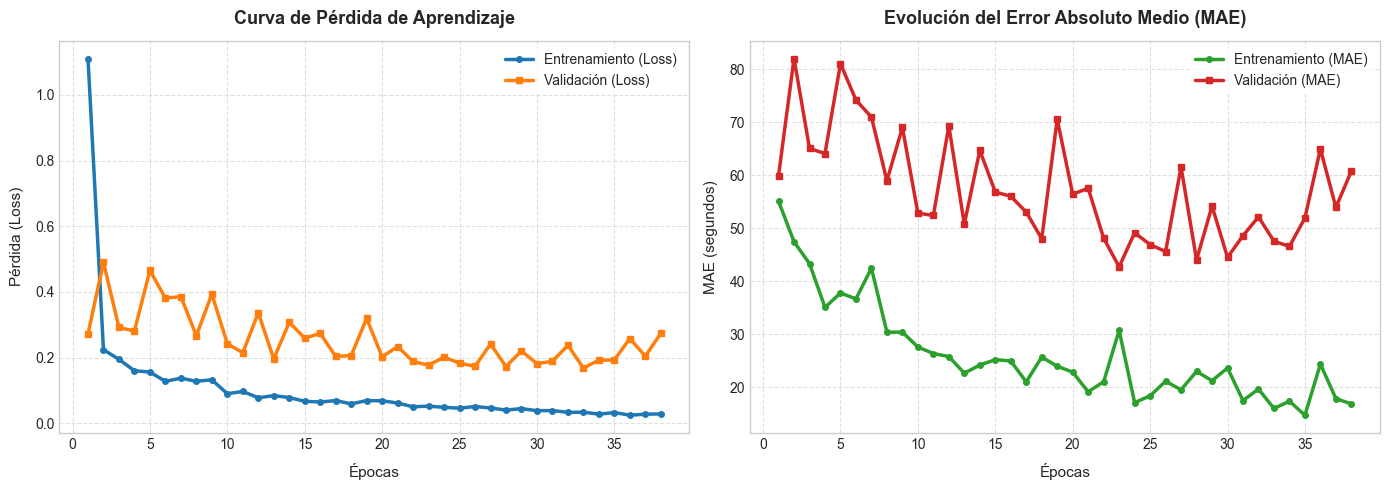

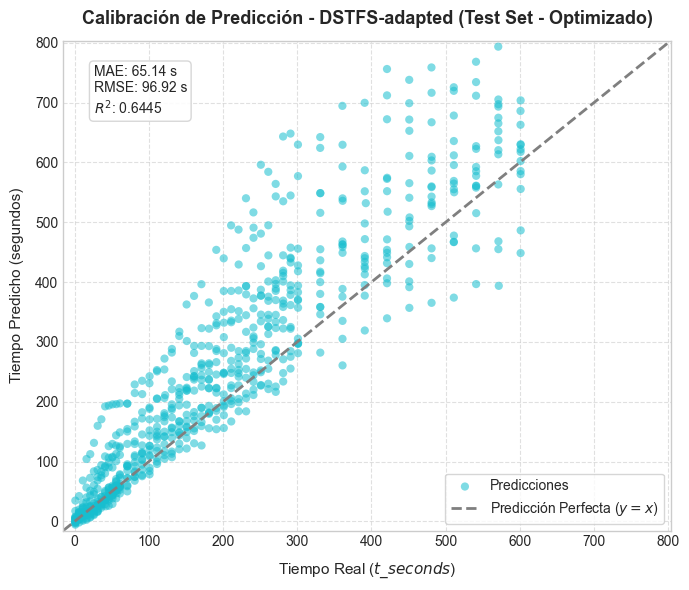

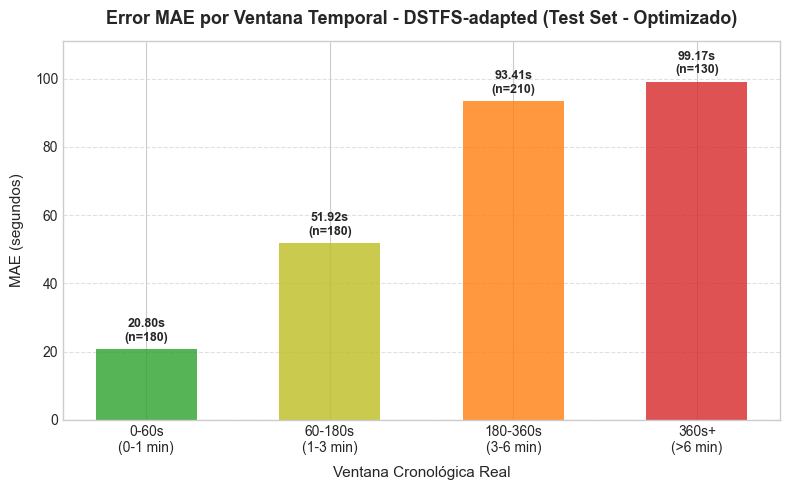

In [9]:
import numpy as np

# Cargar el modelo final entrenado para graficar y evaluar predicciones en Test
model_opt.load_state_dict(torch.load("../DSTFS_adapted_final.pt"))
model_opt.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(dev), y.to(dev)
        pred = model_opt(x)
        # Desescalar predicciones y reales
        y_true.extend((y.cpu().numpy() * CONFIG["time_scale"]).tolist())
        y_pred.extend((pred.cpu().numpy() * CONFIG["time_scale"]).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Curvas de aprendizaje del último fold de validación cruzada (Optimizado)
plot_learning_curves(histories_opt[-1])

# 2. Gráfico de Calibración de Predicciones en el Test Set
plot_prediction_calibration(y_true, y_pred, model_name="DSTFS-adapted (Test Set - Optimizado)")

# 3. Distribución del error por ventana temporal en el Test Set
plot_error_by_time_window(y_true, y_pred, model_name="DSTFS-adapted (Test Set - Optimizado)")